In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\Projects\Data\Supply_Chain_dataset.csv")

df['shipping_date_(DateOrders)'] = pd.to_datetime(df['shipping_date_(DateOrders)'])
df = df.drop(columns="Order_Zipcode")
df = df.drop(columns="Product_Description")
df = df.dropna()

In [86]:
df.info()

<class 'pandas.DataFrame'>
Index: 180508 entries, 0 to 180518
Data columns (total 51 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180508 non-null  str           
 1   Days_for_shipping_(real)       180508 non-null  int64         
 2   Days_for_shipment_(scheduled)  180508 non-null  int64         
 3   Benefit_per_order              180508 non-null  float64       
 4   Sales_per_customer             180508 non-null  float64       
 5   Delivery_Status                180508 non-null  str           
 6   Late_delivery_risk             180508 non-null  int64         
 7   Category_Id                    180508 non-null  int64         
 8   Category_Name                  180508 non-null  str           
 9   Customer_City                  180508 non-null  str           
 10  Customer_Country               180508 non-null  str           
 11  Customer_Email  

In [87]:
df.head()

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_State,Order_Status,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.25000,314.64001,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03,Standard Class
1,TRANSFER,5,4,-249.09000,311.35999,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastan,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18,Standard Class
2,CASH,4,4,-247.78000,309.72000,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastan,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17,Standard Class
3,DEBIT,3,4,22.86000,304.81000,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16,Standard Class
4,PAYMENT,2,4,134.21001,298.25000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15,Standard Class


### EDA_Function : 
Calculates and displays the main descriptive statistics of a numerical variable for exploratory data analysis (EDA).

In [88]:
def EDA (x):
    min_value = x.min()
    max_value = x.max()

    mode_value = x.mode()[0]
    mean_value = x.mean()

    first_quartile = x.quantile(0.25)
    median_value = x.median()
    third_quartile = x.quantile(0.75)

    var = x.var()
    std = x.std()

    skewness = x.skew()
    kurtosis = x.kurtosis()


    print("Minimum: ", min_value)
    print("Maximum: ", max_value)
    print("Mean: ", mean_value)
    print("Mode: ", mode_value)
    print("First Quartile: ", first_quartile)
    print("Median: ", median_value)
    print("Third Quartile: ", third_quartile)
    print("Variance: ", var)
    print("Standard Deviation: ", std)
    print("Skewness: ", skewness)
    print("Kurtosis: ", kurtosis)

In [89]:
EDA(df['Sales_per_customer'])

Minimum:  7.49
Maximum:  1939.98999
Mean:  183.10175147721986
Mode:  122.84
First Quartile:  104.38
Median:  163.99001
Third Quartile:  247.39999
Variance:  14409.980462805093
Standard Deviation:  120.04157805862556
Skewness:  2.8887722987044855
Kurtosis:  23.924135364639525


In [90]:
EDA(df['Benefit_per_order'])

Minimum:  -4274.97998
Maximum:  911.79999
Mean:  21.97156322079908
Mode:  0.0
First Quartile:  7.0
Median:  31.52
Third Quartile:  64.8
Variance:  10906.43110515138
Standard Deviation:  104.43385995524335
Skewness:  -4.7420497754215445
Kurtosis:  71.38010205400339


In [91]:
EDA(df['Order_Profit_Per_Order']) #‼️‼️ we should delete this column because it is the same as Benefit_per_order

Minimum:  -4274.98
Maximum:  911.8
Mean:  21.97156314401578
Mode:  0.0
First Quartile:  7.0
Median:  31.52
Third Quartile:  64.8
Variance:  10906.431125787605
Standard Deviation:  104.4338600540438
Skewness:  -4.742049803514203
Kurtosis:  71.3801023984357


In [92]:
df.drop('Order_Profit_Per_Order', axis=1, inplace=True)

In [93]:
EDA(df['Order_Item_Discount'])

Minimum:  0.0
Maximum:  500.0
Mean:  20.663998380902783
Mode:  0.0
First Quartile:  5.4
Median:  14.0
Third Quartile:  29.99
Variance:  475.2728414350403
Standard Deviation:  21.80075323091017
Skewness:  3.0400344380113955
Kurtosis:  25.233961186727708


In [94]:
EDA(df['Order_Item_Discount']) #‼️‼️ we should delete this column because it is the same as Order_Item_Discount

Minimum:  0.0
Maximum:  500.0
Mean:  20.663998380902783
Mode:  0.0
First Quartile:  5.4
Median:  14.0
Third Quartile:  29.99
Variance:  475.2728414350403
Standard Deviation:  21.80075323091017
Skewness:  3.0400344380113955
Kurtosis:  25.233961186727708


In [95]:
df.drop('Order_Item_Discount', axis=1, inplace=True)

In [96]:
EDA(df['Order_Item_Profit_Ratio'])

Minimum:  -2.75
Maximum:  0.5
Mean:  0.12063880825226585
Mode:  0.48
First Quartile:  0.08
Median:  0.27
Third Quartile:  0.36
Variance:  0.21790777553790394
Standard Deviation:  0.46680592920174435
Skewness:  -2.8934720553984254
Kurtosis:  10.156661051596185


In [97]:
EDA(df['Sales'])

Minimum:  9.99
Maximum:  1999.98999
Mean:  203.7654964663616
Mode:  129.99001
First Quartile:  119.98
Median:  199.92
Third Quartile:  299.95001
Variance:  17495.561186230352
Standard Deviation:  132.2707873501566
Skewness:  2.8845854987454436
Kurtosis:  23.940361379786538


### EDA_Plots(descriptive 0nly):
Here, we will answer some basic business questions.

<Axes: title={'center': 'Type of Product'}, ylabel='Type'>

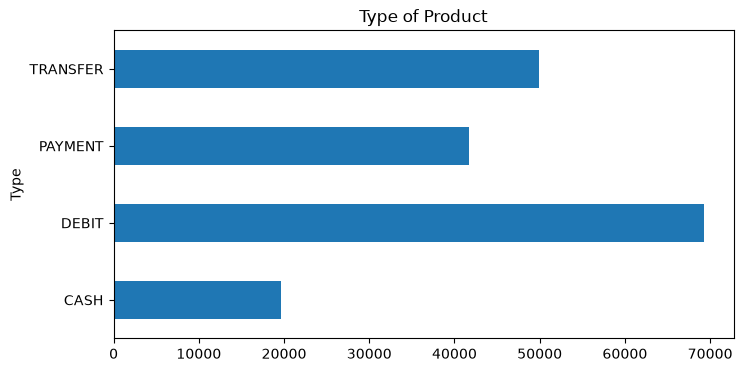

In [98]:
df.groupby(['Type'])['Type'].count().plot(kind='barh', title='Type of Product', figsize=(8, 4))

<Axes: title={'center': 'Number of Products sold'}, xlabel='Product Name', ylabel='Number of Products sold'>

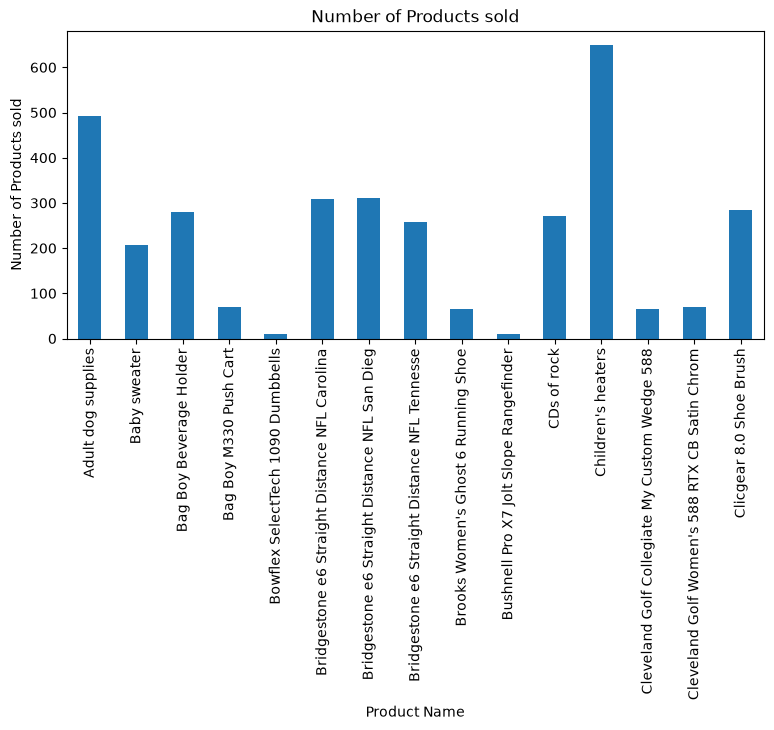

In [102]:
df.groupby(['Product_Name'])['Product_Name'].count().head(15).plot(kind='bar', title='Number of Products sold', figsize=(9, 4), xlabel='Product Name', ylabel='Number of Products sold')

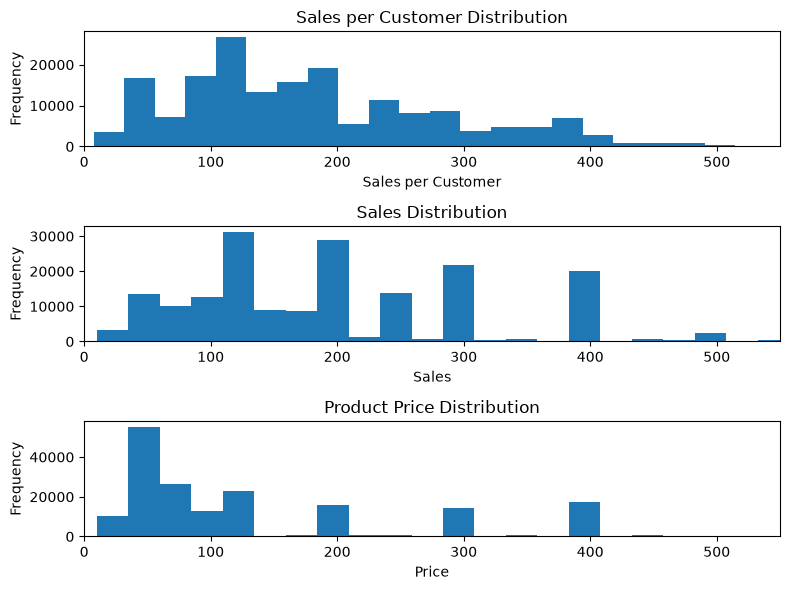

In [107]:
fig, ax = plt.subplots(3, 1, figsize=(8, 6))

ax[0].hist(df['Sales_per_customer'], bins=80)
ax[0].set_title('Sales per Customer Distribution')
ax[0].set_xlabel('Sales per Customer')
ax[0].set_ylabel('Frequency')
ax[0].set_xlim(0, 550)

ax[2].hist(df['Product_Price'], bins=80)
ax[2].set_title('Product Price Distribution')
ax[2].set_xlabel('Price')
ax[2].set_ylabel('Frequency')
ax[2].set_xlim(0, 550)

ax[1].hist(df['Sales'], bins=80)
ax[1].set_title('Sales Distribution')
ax[1].set_xlabel('Sales')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim(0, 550)

plt.tight_layout()
plt.show()